In [1]:
import pickle

importance = pickle.load(open("/mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures/output/importance/shap.pkl", "rb"))

In [2]:
imp = importance[0]
imp
for imp in importance:
    imp.scores *= len(imp.scores)

In [3]:
print(len(imp.tokens))
print(len(imp.scores))
print(len(imp.tokens[:imp.tokens.index('[SEP]')]))
print(imp.tokens[imp.tokens.index('[SEP]')+1:])

130
130
114
['TGTAGG', 'AGTGGGC', 'TGCTCCG', 'ACAAAA', 'AGCC', 'AATGTATT', 'ACCCG', 'TTTTGTGC', 'TAAATC', 'AAATAC', 'GTTTC', 'AAATGAAC', 'TATGC', 'TTAATTTCC', '']


In [4]:
import numpy as np

print(np.mean(imp.scores[:imp.tokens.index('[SEP]')]))
print(np.mean(imp.scores[imp.tokens.index('[SEP]')+1:]))

1.040865243361466
-0.3987093579174657




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



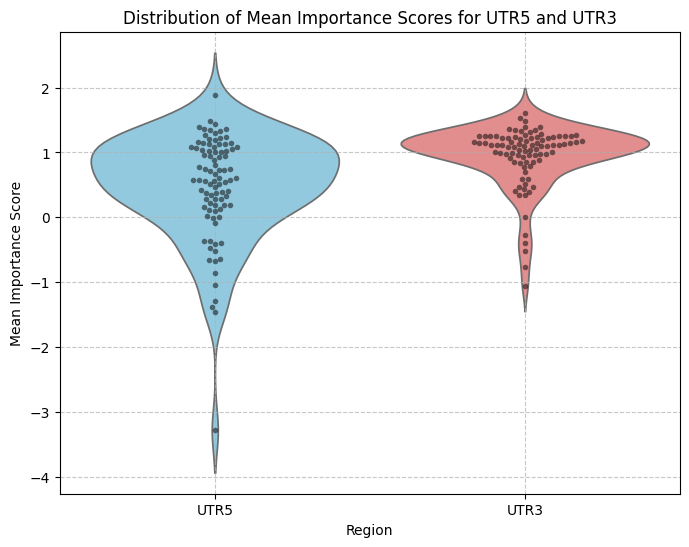

In [5]:
import seaborn as sns
import pandas as pd

utr5 = [np.mean(imp.scores[:imp.tokens.index('[SEP]')]) for imp in importance]
utr3 = [np.mean(imp.scores[imp.tokens.index('[SEP]')+1:]) for imp in importance]

import matplotlib.pyplot as plt

# Prepare data for seaborn
data_utr5 = pd.DataFrame({'value': utr5, 'region': 'UTR5'})
data_utr3 = pd.DataFrame({'value': utr3, 'region': 'UTR3'})
plot_data = pd.concat([data_utr5, data_utr3])

# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='region', y='value', data=plot_data, inner=None, palette={"UTR5": "skyblue", "UTR3": "lightcoral"})
sns.swarmplot(x='region', y='value', data=plot_data, color='black', size=4, alpha=0.5)
#sns.stripplot(x='region', y='value', data=plot_data, jitter=True, color='black', size=3, alpha=0.5)

plt.title('Distribution of Mean Importance Scores for UTR5 and UTR3')
plt.ylabel('Mean Importance Score')
plt.xlabel('Region')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



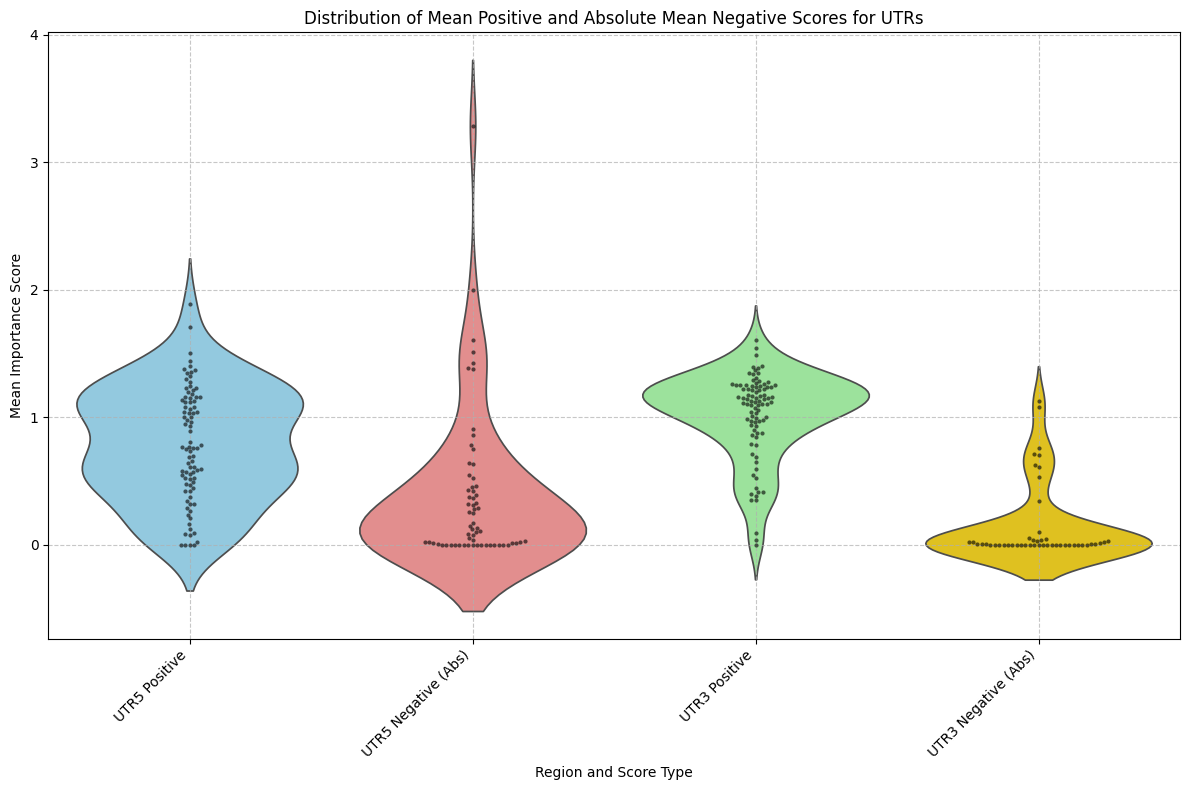

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Initialize lists to store the calculated means
utr5_positive_means = []
utr5_negative_abs_means = []
utr3_positive_means = []
utr3_negative_abs_means = []

# Iterate through each explanation object in the importance list
for imp_item in importance:
    scores_1d = imp_item.scores.flatten()  # Flatten the 2D scores array to 1D
    tokens = imp_item.tokens
    
    try:
        sep_index = tokens.index('[SEP]')
    except ValueError:
        # Skip if [SEP] token is not found, though unlikely based on data structure
        print(f"Warning: '[SEP]' token not found in an item. Skipping.")
        continue

    # Scores for UTR5 region (including the initial empty token's score, consistent with CELL 4)
    utr5_region_scores = scores_1d[:sep_index]
    # Scores for UTR3 region
    utr3_region_scores = scores_1d[sep_index+1:]

    # Calculate means for UTR5
    utr5_positive_scores = utr5_region_scores[utr5_region_scores > 0]
    utr5_negative_scores = utr5_region_scores[utr5_region_scores < 0]
    
    utr5_positive_means.append(np.mean(utr5_positive_scores) if len(utr5_positive_scores) > 0 else np.nan)
    utr5_negative_abs_means.append(np.abs(np.mean(utr5_negative_scores)) if len(utr5_negative_scores) > 0 else np.nan)

    # Calculate means for UTR3
    utr3_positive_scores = utr3_region_scores[utr3_region_scores > 0]
    utr3_negative_scores = utr3_region_scores[utr3_region_scores < 0]

    utr3_positive_means.append(np.mean(utr3_positive_scores) if len(utr3_positive_scores) > 0 else np.nan)
    utr3_negative_abs_means.append(np.abs(np.mean(utr3_negative_scores)) if len(utr3_negative_scores) > 0 else np.nan)

# Prepare data for seaborn plot
data_utr5_pos = pd.DataFrame({'value': utr5_positive_means, 'category': 'UTR5 Positive'})
data_utr5_neg_abs = pd.DataFrame({'value': utr5_negative_abs_means, 'category': 'UTR5 Negative (Abs)'})
data_utr3_pos = pd.DataFrame({'value': utr3_positive_means, 'category': 'UTR3 Positive'})
data_utr3_neg_abs = pd.DataFrame({'value': utr3_negative_abs_means, 'category': 'UTR3 Negative (Abs)'})

# Concatenate all dataframes
plot_data_new = pd.concat([data_utr5_pos, data_utr5_neg_abs, data_utr3_pos, data_utr3_neg_abs])
# Drop rows where 'value' is NaN (i.e., no positive/negative scores in a region for an item)
plot_data_new = plot_data_new.dropna(subset=['value'])

# Create the violin plot
plt.figure(figsize=(12, 8))
palette = {
    "UTR5 Positive": "skyblue", 
    "UTR5 Negative (Abs)": "lightcoral",
    "UTR3 Positive": "lightgreen",
    "UTR3 Negative (Abs)": "gold"
}
sns.violinplot(x='category', y='value', data=plot_data_new, inner=None, palette=palette)
sns.swarmplot(x='category', y='value', data=plot_data_new, color='black', size=3, alpha=0.6)

plt.title('Distribution of Mean Positive and Absolute Mean Negative Scores for UTRs')
plt.ylabel('Mean Importance Score')
plt.xlabel('Region and Score Type')
plt.xticks(rotation=45, ha="right") # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout
plt.show()

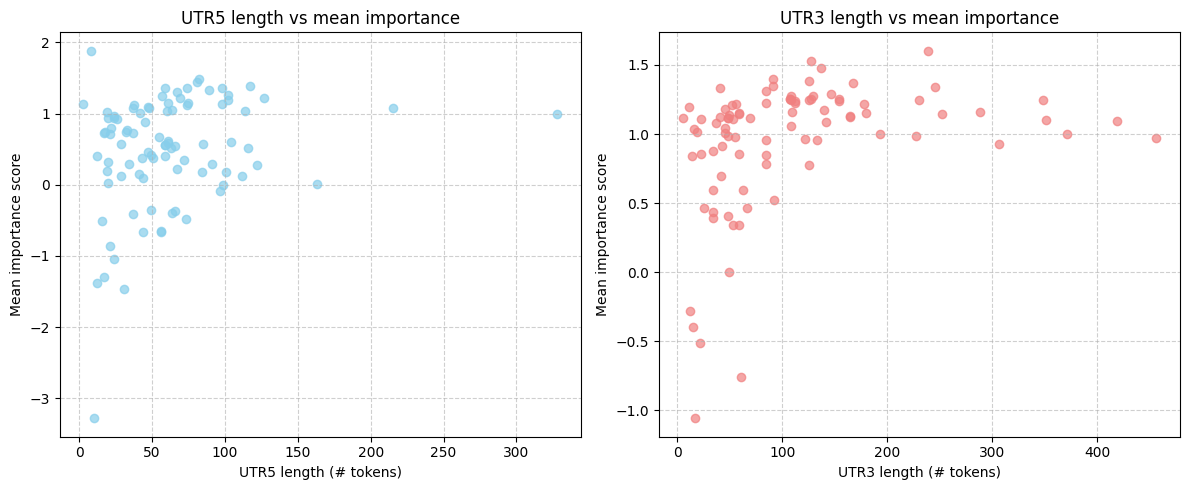

In [7]:
# compute UTR5/UTR3 lengths (#tokens before/after '[SEP]')
utr5_lengths = [imp_item.tokens.index('[SEP]') for imp_item in importance]
utr3_lengths = [len(imp_item.tokens) - imp_item.tokens.index('[SEP]') - 1
                for imp_item in importance]

# scatter plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(utr5_lengths, utr5, color='skyblue', alpha=0.7)
plt.title('UTR5 length vs mean importance')
plt.xlabel('UTR5 length (# tokens)')
plt.ylabel('Mean importance score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,2,2)
plt.scatter(utr3_lengths, utr3, color='lightcoral', alpha=0.7)
plt.title('UTR3 length vs mean importance')
plt.xlabel('UTR3 length (# tokens)')
plt.ylabel('Mean importance score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

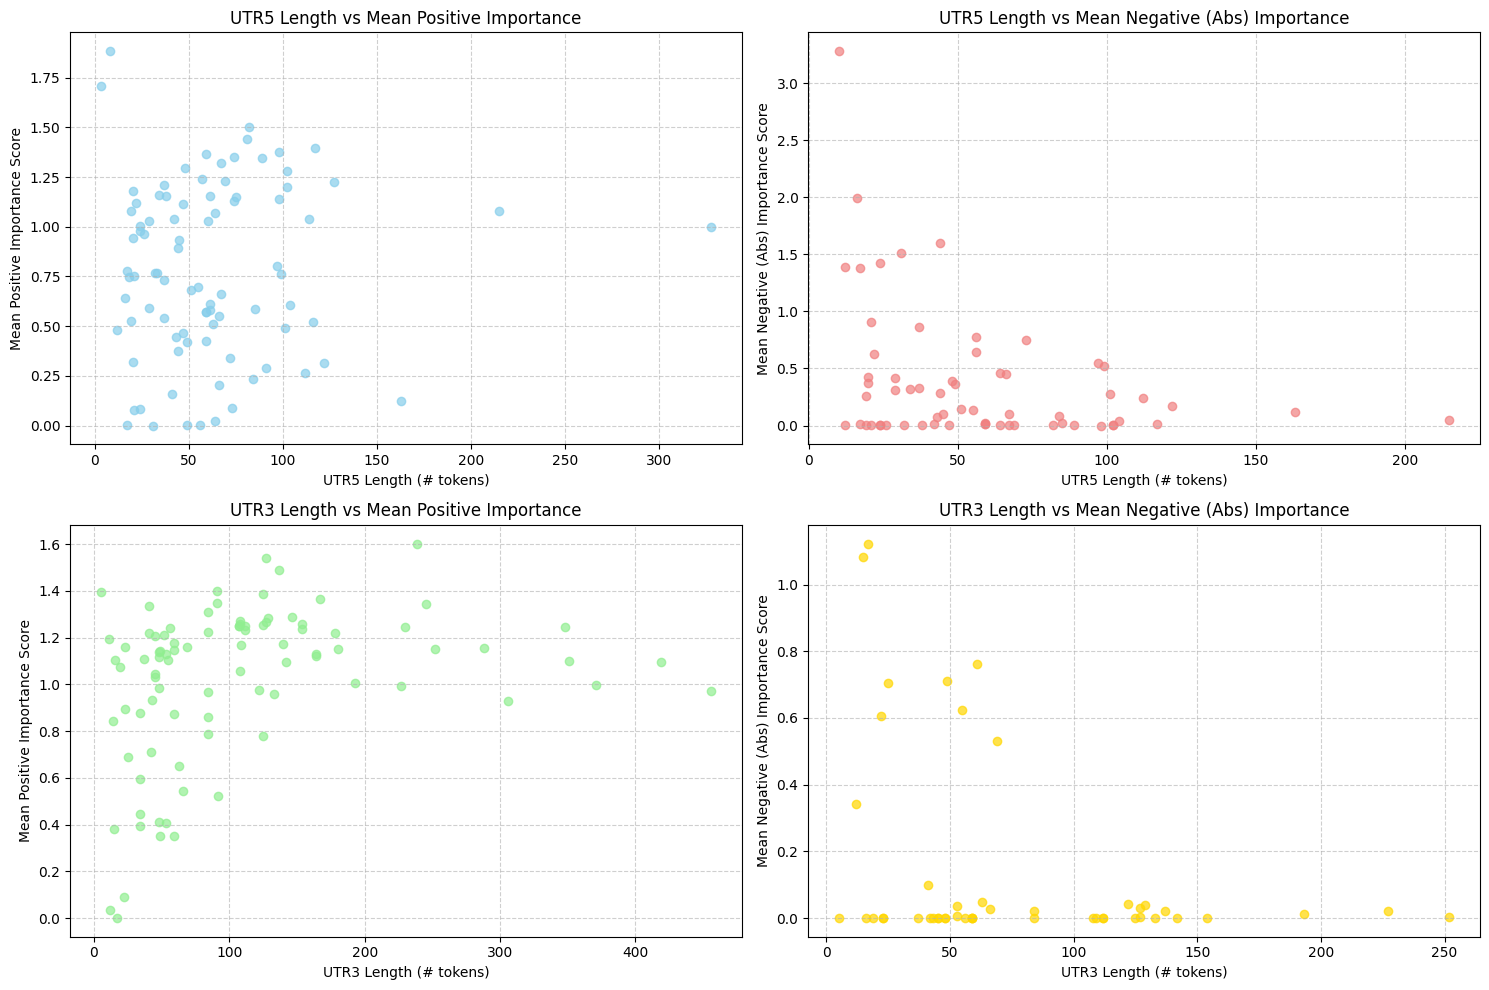

In [8]:
# Scatter plots for positive and negative scores vs lengths

plt.figure(figsize=(15, 10))

# UTR5 positive scores vs length
plt.subplot(2, 2, 1)
plt.scatter(utr5_lengths, utr5_positive_means, color='skyblue', alpha=0.7, label='Positive Scores')
plt.title('UTR5 Length vs Mean Positive Importance')
plt.xlabel('UTR5 Length (# tokens)')
plt.ylabel('Mean Positive Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)

# UTR5 negative absolute scores vs length
plt.subplot(2, 2, 2)
plt.scatter(utr5_lengths, utr5_negative_abs_means, color='lightcoral', alpha=0.7, label='Negative Scores (Abs)')
plt.title('UTR5 Length vs Mean Negative (Abs) Importance')
plt.xlabel('UTR5 Length (# tokens)')
plt.ylabel('Mean Negative (Abs) Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)

# UTR3 positive scores vs length
plt.subplot(2, 2, 3)
plt.scatter(utr3_lengths, utr3_positive_means, color='lightgreen', alpha=0.7, label='Positive Scores')
plt.title('UTR3 Length vs Mean Positive Importance')
plt.xlabel('UTR3 Length (# tokens)')
plt.ylabel('Mean Positive Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)

# UTR3 negative absolute scores vs length
plt.subplot(2, 2, 4)
plt.scatter(utr3_lengths, utr3_negative_abs_means, color='gold', alpha=0.7, label='Negative Scores (Abs)')
plt.title('UTR3 Length vs Mean Negative (Abs) Importance')
plt.xlabel('UTR3 Length (# tokens)')
plt.ylabel('Mean Negative (Abs) Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
for l,m in zip(utr5_lengths,utr5_negative_abs_means):
    print(f"{l}\t{m}")

60	nan
21	6.408251546293047e-06
33	nan
12	1.385980196914234
163	0.11908699149465188
112	0.2449809776630068
98	2.9896445249569144e-07
47	nan
98	nan
102	2.8712353611439503e-06
10	3.280797126990204
69	1.5411943465829942e-05
67	1.0373120324493982e-05
61	nan
61	nan
20	0.37645398844039624
51	0.1489214895672852
215	0.0517970535011904
81	nan
127	nan
66	nan
3	nan
16	1.9942407113730194
24	1.5222052695141207e-05
49	nan
43	0.07665921692986652
44	0.28293129224970265
22	0.6278939673150993
104	0.03670781089130231
41	nan
82	1.0972234605791526e-05
73	0.7493363576472993
44	1.6029087305990954
17	1.3764598576468825
66	0.4496539900747086
37	nan
47	8.370954908680799e-06
32	3.7534536342857236e-06
37	0.32630035927947554
59	0.020259966159472686
59	nan
12	0.004768963929394622
42	0.015113120556086712
8	nan
64	5.129932155413464e-07
67	0.1030085011364875
63	nan
61	nan
74	nan
37	0.8632314600865196
64	0.45910860837450257
19	0.2576828500767326
49	0.36387824583591116
84	0.08550607449668436
85	0.023817372123030627
17	0